In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/Astro/Code/PG1522+101/science.mplstyle')

# Constants

In [3]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [4]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [5]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [6]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [7]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        # Convert to linear T, then take natural log
        return np.log(10**logT)
    return -np.inf

In [8]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [9]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [10]:
gen_b(4., 0, A_dict['H'])

12.844232700646511

In [11]:
gen_b(4., 0, A_dict['He'])

6.445563226098044

In [12]:
gen_b(4.5, 0, A_dict['C'])

6.616714331124134

In [13]:
gen_b(4., 0, A_dict['Si'])

2.433273287255247

In [14]:
gen_b(5, 0, A_dict['Mg'])

8.271497744829851

In [15]:
gen_b(4, 0, A_dict['N'])

3.445593622658098

In [16]:
gen_b(3.9, 5.6, A_dict['H'])

12.743773199136745

In [17]:
gen_b(3.9, 5.6, A_dict['S'])

5.956511595142642

In [18]:
gen_b(3.5, 5.6, A_dict['Mg'])

5.789953095692608

In [19]:
gen_b(6.3, 0, A_dict['O'])

45.54633357551483

In [20]:
gen_b(4, 0, A_dict['Si'])

2.433273287255247

# z=0.67

## c1

### c1H

In [21]:
b_list = [[['HI', 'H', 37, 1.5],
          ['CIII', 'C', 31, 2],
          ['CIV', 'C', 33, 4.5],
          ['OIII', 'O', 34, 2]
          ]]

In [22]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [23]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [25]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [26]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

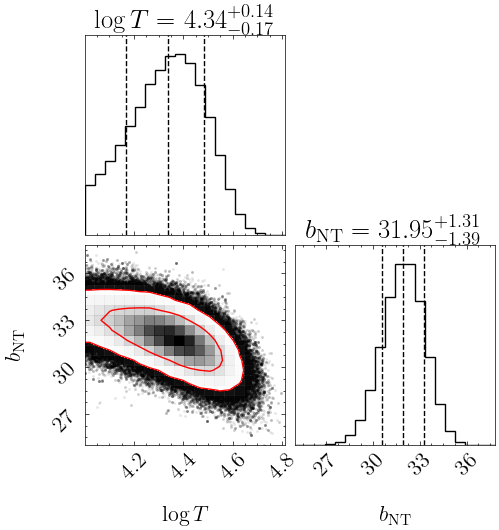

In [27]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [29]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.691939200523127

### c1L

In [27]:
b_list = [[
          ['OIV', 'O', 30, 2],
          ['OVI', 'O', 32, 3]
          ]]

In [28]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [29]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [221]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [31]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

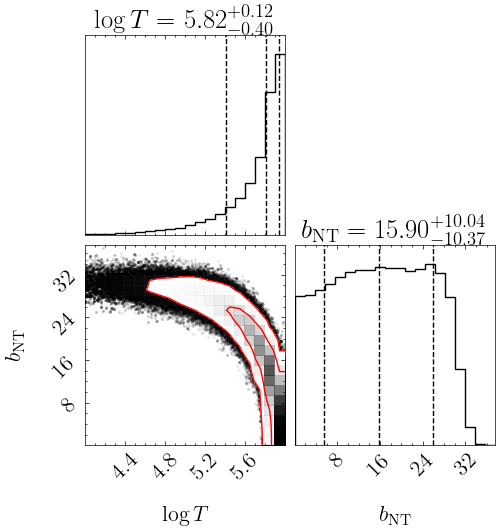

In [32]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([ 54792.,  58266.,  61814.,  66320.,  74355.,  85032., 105743.,
        141333., 153539.,  98806.]),
 array([ 10003.2299565 , 109002.7615557 , 208002.2931549 , 307001.82475411,
        406001.35635331, 505000.88795251, 604000.41955172, 702999.95115092,
        801999.48275012, 900999.01434932, 999998.54594853]),
 <BarContainer object of 10 artists>)

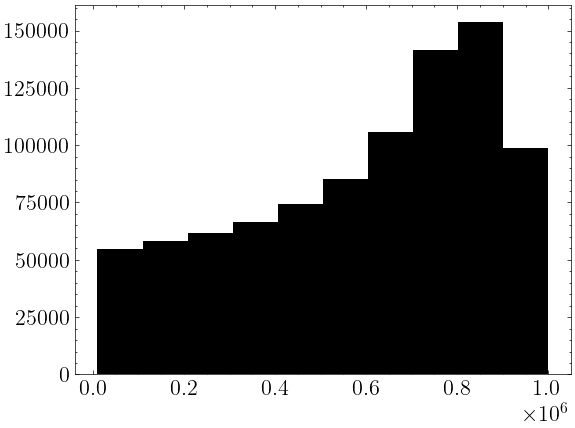

In [33]:
plt.hist(10**flat_samples['logT'])

In [34]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.069670293484817, 5.999182865357982)

In [35]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

33.235700031194284

# z=1.04

## c1

### c1H

In [30]:
b_list = [[['HI', 'H', 18, 1.5],
           ['HeI', 'He', 9.7, 0.8],
           ['CIV', 'C', 6.4, 0.4],
           ]]

In [31]:
pos = np.array([4.6, 32]) + 1e-3 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [32]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [34]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [35]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

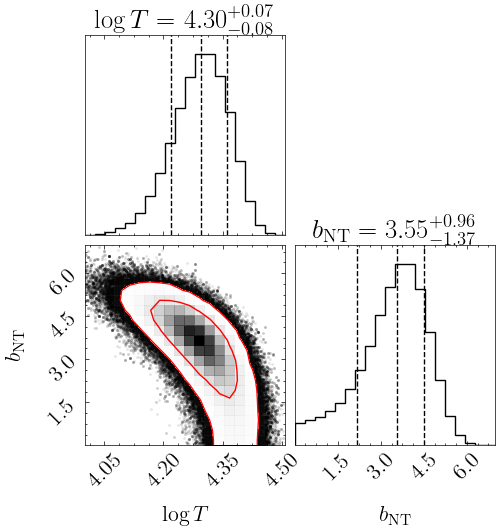

In [36]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [50]:
np.median(flat_samples['b_NT'])

3.4683958853047945

In [53]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

6.081517722737895

In [52]:
np.median(flat_samples['b_NT'])-np.percentile(flat_samples['b_NT'],100*(1-cdf_1sig))

1.5538211405903881

### c1L

In [27]:
b_list = [[['OV', 'O', 23, 1],
           ]]

In [28]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [29]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [31]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [32]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

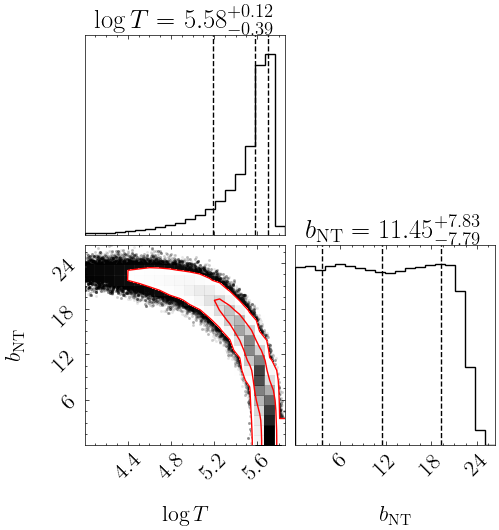

In [33]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [34]:
np.percentile(flat_samples['logT'],100*cdf_3sig), np.percentile(flat_samples['b_NT'],100*cdf_3sig)

(5.794588349563722, 24.362902310026268)

## c2

In [37]:
b_list = [[['HI', 'H', 11, 2],
           ['HeI', 'He', 8, 1.5],
           ['CIV', 'C', 6.1, 0.5],
           ]]

In [38]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [39]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [41]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [42]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

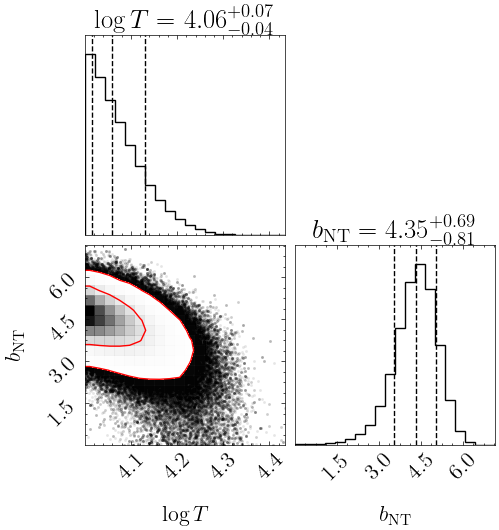

In [43]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [44]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.3081013063603715

In [45]:
np.median(flat_samples['b_NT'])

4.3518150130105955

## c3

### c3H

In [46]:
b_list = [[['HI', 'H', 13, 2.5],
          ['CIV', 'C', 10, 1]]]

In [47]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [48]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [50]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [51]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

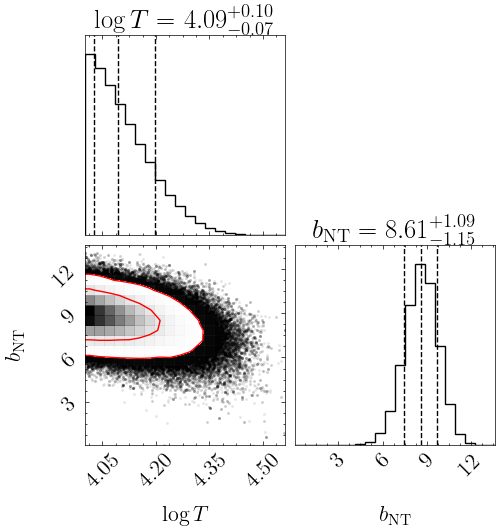

In [52]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [53]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.429673897464844

### c3L

In [71]:
b_list = [[['OV', 'O', 26, 2]]]

In [72]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [73]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [75]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [76]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

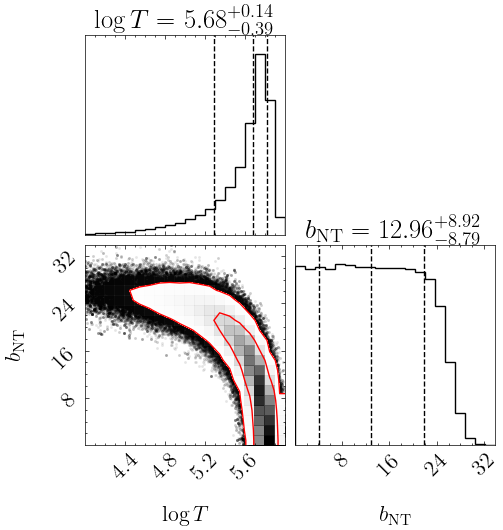

In [77]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [78]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

5.965556662547007

In [79]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

29.505001584985685

## c4

In [54]:
b_list = [[['HI', 'H', 20, 5.5],
          ['CIV', 'C', 8.2, 0.6]]]

In [55]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [56]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [58]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [59]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

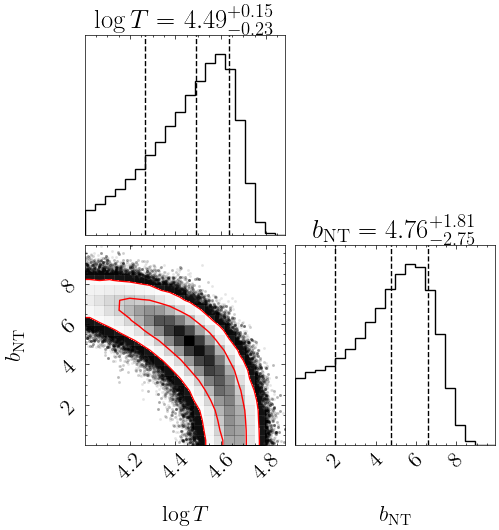

In [60]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [61]:
np.percentile(flat_samples['logT'], 100*cdf_1sig)-np.median(flat_samples['logT'])

0.1470488104632537

In [62]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

8.625237180970068

In [256]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.8006965726284605

# z=1.09

## c1

### c1H

In [63]:
b_list = [[['HI', 'H', 21, 2.5],
          ['CIV', 'C', 18.0, 0.3],
          ['NIV', 'N', 13, 5.5],
          ['OIII', 'O', 25, 4]
          ]]

In [64]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(400, 2)
nwalkers, ndim = pos.shape

In [65]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [67]:
#sampler.run_mcmc(pos, 8000, progress=True)

In [68]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

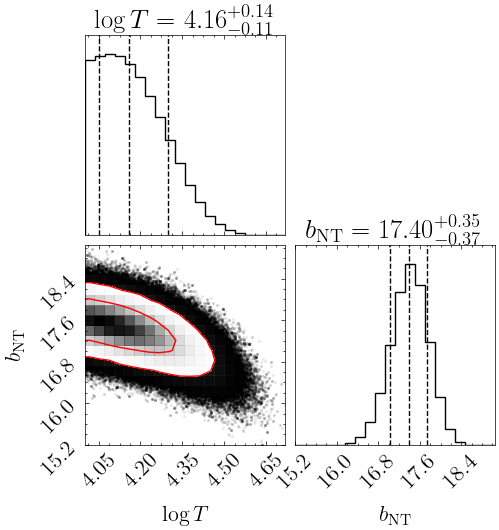

In [69]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [70]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.551779990910088

### c1L

In [106]:
b_list = [[['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [107]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [108]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [110]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [111]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

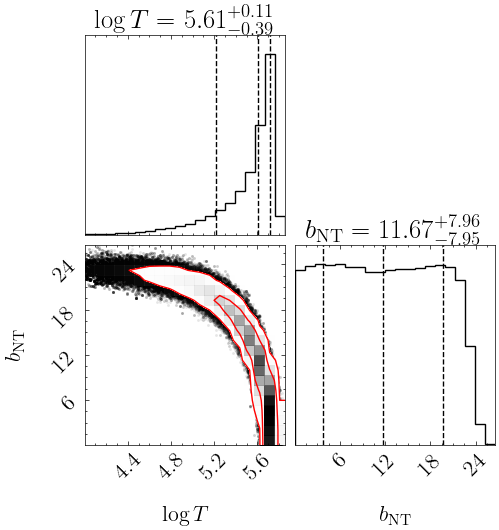

In [112]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [113]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.068017676673675, 5.8048376209588035)

In [114]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

24.695267905005345

# z=1.16

## c2

In [79]:
b_list = [[['HI', 'H', 19, 2.5],
          ['HeI', 'He', 12, 1],
          ['CIV', 'C', 10.6, 0.4],
          ['OIII', 'O', 14, 3],
          ['OIV', 'O', 16, 2],
          ['OV', 'O', 11, 3],
          ['SiIII', 'Si', 11, 2.5]]]

In [80]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [81]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [83]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [84]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

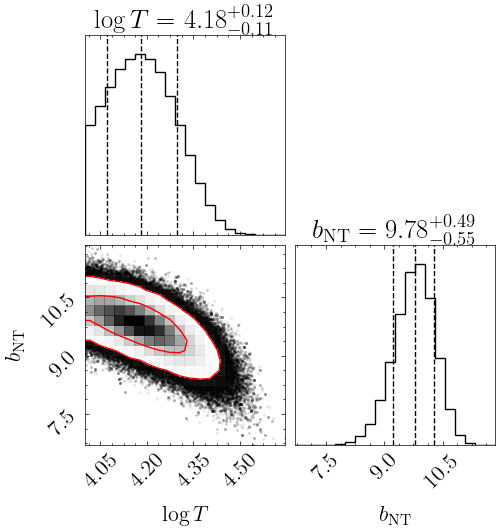

In [85]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [86]:
np.median(flat_samples['b_NT'])-np.percentile(flat_samples['b_NT'], 100*(1-cdf_1sig))

0.5519135203112899

In [87]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.49613454889971

## c1H

In [71]:
b_list = [[['HI', 'H', 31, 3],
           ['CIV', 'C', 27, 3],
          ['OIV', 'O', 28, 7],
          ['OV', 'O', 29, 2.5]]]

In [72]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [73]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [75]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [76]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

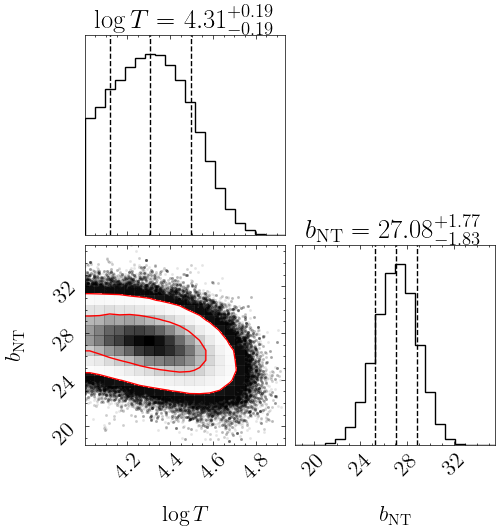

In [77]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [78]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.782471847212189, 32.303126605440596)

## c1L

In [179]:
b_list = [[
          ['OVI', 'O', 45, 15]]]

In [180]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [181]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [183]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [184]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

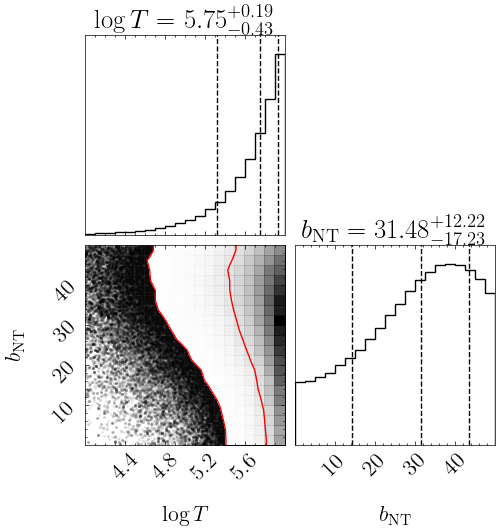

In [185]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [188]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

49.94702301036304

In [186]:
np.median(flat_samples['b_NT'])-np.percentile(flat_samples['b_NT'], 100*(1-cdf_1sig))

17.32161988680193

In [187]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

5.999599326769822

# z=1.22

## c1

In [118]:
b_list = [[['HI', 'H', 25, 4],
           ['CIV', 'C', 16, 3],
          ['OVI', 'O', 21, 2]]]

In [119]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [120]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [122]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [123]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

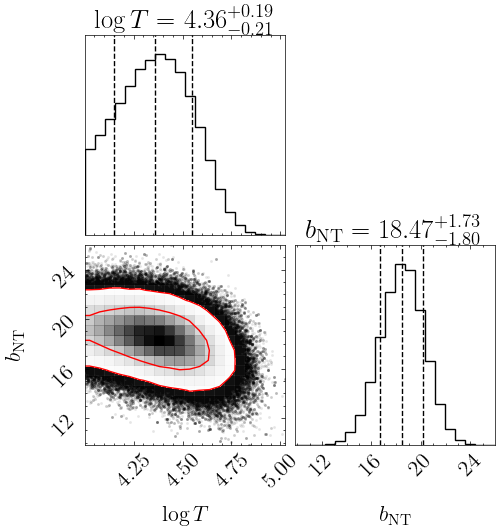

In [124]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [125]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.844322305555339, 23.521051149592466)

# z=1.26

## c1

In [126]:
b_list = [[['HI', 'H', 20, 2],
          ['CIV', 'C', 6.0, 0.7],
          ]]

In [127]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [128]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [131]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [132]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

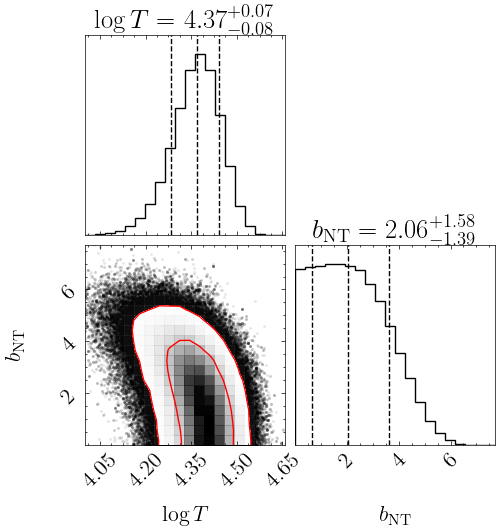

In [133]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [134]:
np.median(flat_samples['logT'])

4.368606020566245

In [135]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.060047670604937, 4.564893922151878)

In [136]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

6.154743322761415

# z=1.27

## c1

In [88]:
b_list = [[['HI', 'H', 24, 3],
          ['CIV', 'C', 10.6, 0.2],
          ['OIV', 'O', 14, 1],
          ['NIV', 'N', 12, 4.5]
          ]]

In [89]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [90]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [92]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [93]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

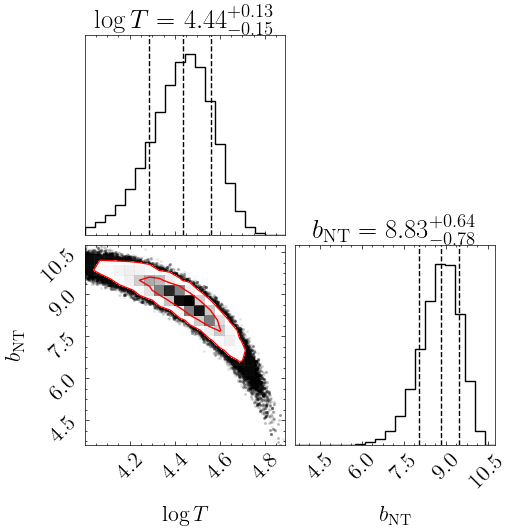

In [94]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [95]:
np.median(flat_samples['logT'])-np.percentile(flat_samples['logT'],100*(1-cdf_1sig))

0.15188529937915618

In [96]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.764047908364074, 10.338660226287974)

## c2

In [106]:
b_list = [[['HI', 'H', 38, 9.5],
          ['CIV', 'C', 9.2, 0.3],
          ['OIV', 'O', 13, 2],
          ]]

In [107]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [108]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [110]:
#sampler.run_mcmc(pos, 5000, progress=True)

In [111]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

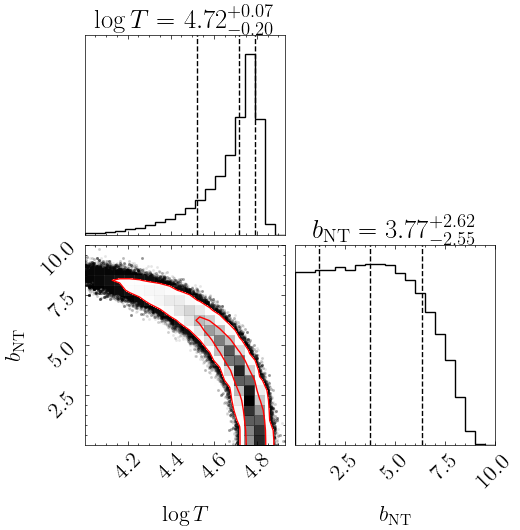

In [112]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [113]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.861773543687842, 8.819548938195013)

# DRAFT

## z=0.72

In [69]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 15, 4],
          ['OIII', 'O', 12, 2]]]

In [70]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [71]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [72]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.65it/s]


State([[ 4.5384403   8.09929585]
 [ 4.47312911 12.56506458]
 [ 4.51935019  9.9915456 ]
 [ 4.43163142 15.65060414]
 [ 4.52375086  9.37540148]
 [ 4.54954478  6.62458899]
 [ 4.52685679 10.13970275]
 [ 4.42873199 14.08212653]
 [ 4.50605638 12.29829318]
 [ 4.50825934 10.95642096]
 [ 4.52653629 10.0437353 ]
 [ 4.43088461 14.06331714]
 [ 4.52991303 10.05491318]
 [ 4.5366154   8.2728032 ]
 [ 4.57220497  8.25733952]
 [ 4.47898707 12.46445221]
 [ 4.57009848  8.66609242]
 [ 4.50306259 11.53717785]
 [ 4.36597978 15.86877089]
 [ 4.56793488  9.68422604]
 [ 4.45187513 13.86462879]
 [ 4.56351901  5.3446461 ]
 [ 4.59466794  3.46409942]
 [ 4.53785633  9.65510504]
 [ 4.55211141  8.05027689]
 [ 4.49100075 11.93868292]
 [ 4.54138785 10.3322841 ]
 [ 4.54959999  9.2107803 ]
 [ 4.42833962 14.57471485]
 [ 4.51295023 12.04145711]
 [ 4.59385652  7.83400509]
 [ 4.46092935 12.78548227]
 [ 4.5263072  12.37414796]
 [ 4.48133168 13.77105522]
 [ 4.49751563 10.66109777]
 [ 4.53237196  9.36835803]
 [ 4.53007861 10.24665

In [73]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

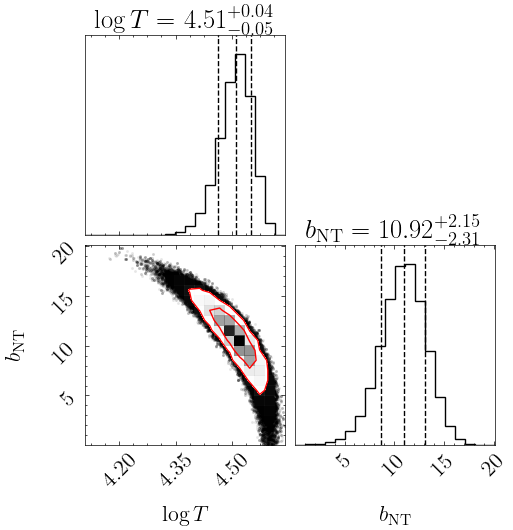

In [74]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [75]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

12.821218751413966

In [76]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

12.567972555170432

In [77]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

12.375375197197565

In [78]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

12.088713599866455

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

11.898696060874855

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

11.805498059645785

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

11.77212289470581

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

11.670068905881259

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

11.358898777000608